# SDNET2018 Data Exploration, Balancing, and Augmentation

This notebook explores the local SDNET2018-style folder under `dataset/`, profiles class imbalance, prepares train/validation/test splits, creates balanced training manifests, and previews image transformations that are useful for crack-detection experiments.


## Imports And Configuration

These imports cover data discovery, plotting, balancing, and Albumentations-based augmentation previews.


In [1]:
from __future__ import annotations

import random
import warnings
from collections import Counter
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", message="Error fetching version info")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_ROOT = Path("dataset")
MANIFEST_DIR = Path("artifacts") / "manifests"
PLOT_DIR = Path("artifacts") / "plots"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SURFACE_NAMES = {
    "D": "Deck",
    "P": "Pavement",
    "W": "Wall",
}

SUBCLASS_NAMES = {
    "CD": "Cracked",
    "UD": "Uncracked",
    "CP": "Cracked",
    "UP": "Uncracked",
    "CW": "Cracked",
    "UW": "Uncracked",
}

CRACK_COLORS = {
    "Cracked": "#d95f02",
    "Uncracked": "#1b9e77",
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Expected the SDNET2018 dataset under {DATASET_ROOT.resolve()}, but the folder was not found."
    )


## Build A Manifest From The Folder Structure

The local dataset uses the SDNET2018 hierarchy:

- `D/CD`, `D/UD` for deck images
- `P/CP`, `P/UP` for pavement images
- `W/CW`, `W/UW` for wall images

The cell below scans those folders and creates a dataframe that will drive the rest of the notebook.


In [2]:
def collect_sdnet2018_manifest(root: Path) -> pd.DataFrame:
    records = []

    for surface_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        surface_code = surface_dir.name
        surface_name = SURFACE_NAMES.get(surface_code, surface_code)

        for subclass_dir in sorted(path for path in surface_dir.iterdir() if path.is_dir()):
            subclass_code = subclass_dir.name
            crack_status = SUBCLASS_NAMES.get(subclass_code, "Unknown")
            binary_label = int(crack_status == "Cracked")

            for image_path in sorted(subclass_dir.glob("*.jpg")):
                records.append(
                    {
                        "path": image_path.resolve(),
                        "relative_path": image_path.as_posix(),
                        "surface_code": surface_code,
                        "surface_name": surface_name,
                        "subclass_code": subclass_code,
                        "crack_status": crack_status,
                        "binary_label": binary_label,
                        "surface_class": f"{surface_code}/{subclass_code}",
                    }
                )

    manifest = pd.DataFrame(records)

    if manifest.empty:
        raise RuntimeError(
            "No JPG images were found under the dataset folder. Please verify the SDNET2018 path."
        )

    return manifest


manifest_df = collect_sdnet2018_manifest(DATASET_ROOT)
display(manifest_df.head())
print(f"Collected {len(manifest_df):,} image records from {DATASET_ROOT.resolve()}")


,path,relative_path,surface_code,surface_name,subclass_code,crack_status,binary_label,surface_class
0,C:\Users\sumit\Desktop\kavita_capstone\dataset...,dataset/D/CD/7001-115.jpg,D,Deck,CD,Cracked,1,D/CD
1,C:\Users\sumit\Desktop\kavita_capstone\dataset...,dataset/D/CD/7001-139.jpg,D,Deck,CD,Cracked,1,D/CD
2,C:\Users\sumit\Desktop\kavita_capstone\dataset...,dataset/D/CD/7001-151.jpg,D,Deck,CD,Cracked,1,D/CD
3,C:\Users\sumit\Desktop\kavita_capstone\dataset...,dataset/D/CD/7001-157.jpg,D,Deck,CD,Cracked,1,D/CD
4,C:\Users\sumit\Desktop\kavita_capstone\dataset...,dataset/D/CD/7001-169.jpg,D,Deck,CD,Cracked,1,D/CD


Collected 56,092 image records from C:\Users\sumit\Desktop\kavita_capstone\dataset


## Dataset Overview And Image Geometry

This cell summarizes dataset size, the crack/non-crack split, and the observed image shapes from a sample of files.


In [3]:
def load_grayscale(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    return image


def sample_image_shapes(df: pd.DataFrame, sample_size: int = 512) -> pd.DataFrame:
    sampled_paths = df["path"].sample(n=min(sample_size, len(df)), random_state=SEED)
    shape_counter: Counter[tuple[int, int]] = Counter()

    for image_path in sampled_paths:
        shape_counter[load_grayscale(Path(image_path)).shape] += 1

    shape_rows = [
        {"image_shape": f"{height}x{width}", "count_in_sample": count}
        for (height, width), count in sorted(shape_counter.items())
    ]

    return pd.DataFrame(shape_rows).sort_values("count_in_sample", ascending=False)


cracked_images = int(manifest_df["binary_label"].sum())
uncracked_images = int(len(manifest_df) - cracked_images)

overview_df = pd.DataFrame(
    [
        {"metric": "Total images", "value": f"{len(manifest_df):,}"},
        {"metric": "Surface types", "value": manifest_df["surface_name"].nunique()},
        {"metric": "Subclass folders", "value": manifest_df["surface_class"].nunique()},
        {"metric": "Cracked images", "value": f"{cracked_images:,}"},
        {"metric": "Uncracked images", "value": f"{uncracked_images:,}"},
        {"metric": "Crack ratio", "value": f"{manifest_df['binary_label'].mean():.2%}"},
    ]
)

shape_df = sample_image_shapes(manifest_df)

display(overview_df)
display(shape_df)


,metric,value
0,Total images,"56,092"
1,Surface types,3
2,Subclass folders,6
3,Cracked images,"8,484"
4,Uncracked images,"47,608"
5,Crack ratio,15.13%


,image_shape,count_in_sample
0,256x256,512


## Class Balance At A Glance

SDNET2018 is usually imbalanced, especially between cracked and uncracked folders. These plots make that imbalance easy to inspect before training.


Max/min imbalance across the six SDNET2018 folders: 10.73x
Saved class balance plot to artifacts\plots\sdnet2018_class_balance.png


,surface_class,count
0,D/CD,2025
1,D/UD,11595
2,P/CP,2608
3,P/UP,21726
4,W/CW,3851
5,W/UW,14287


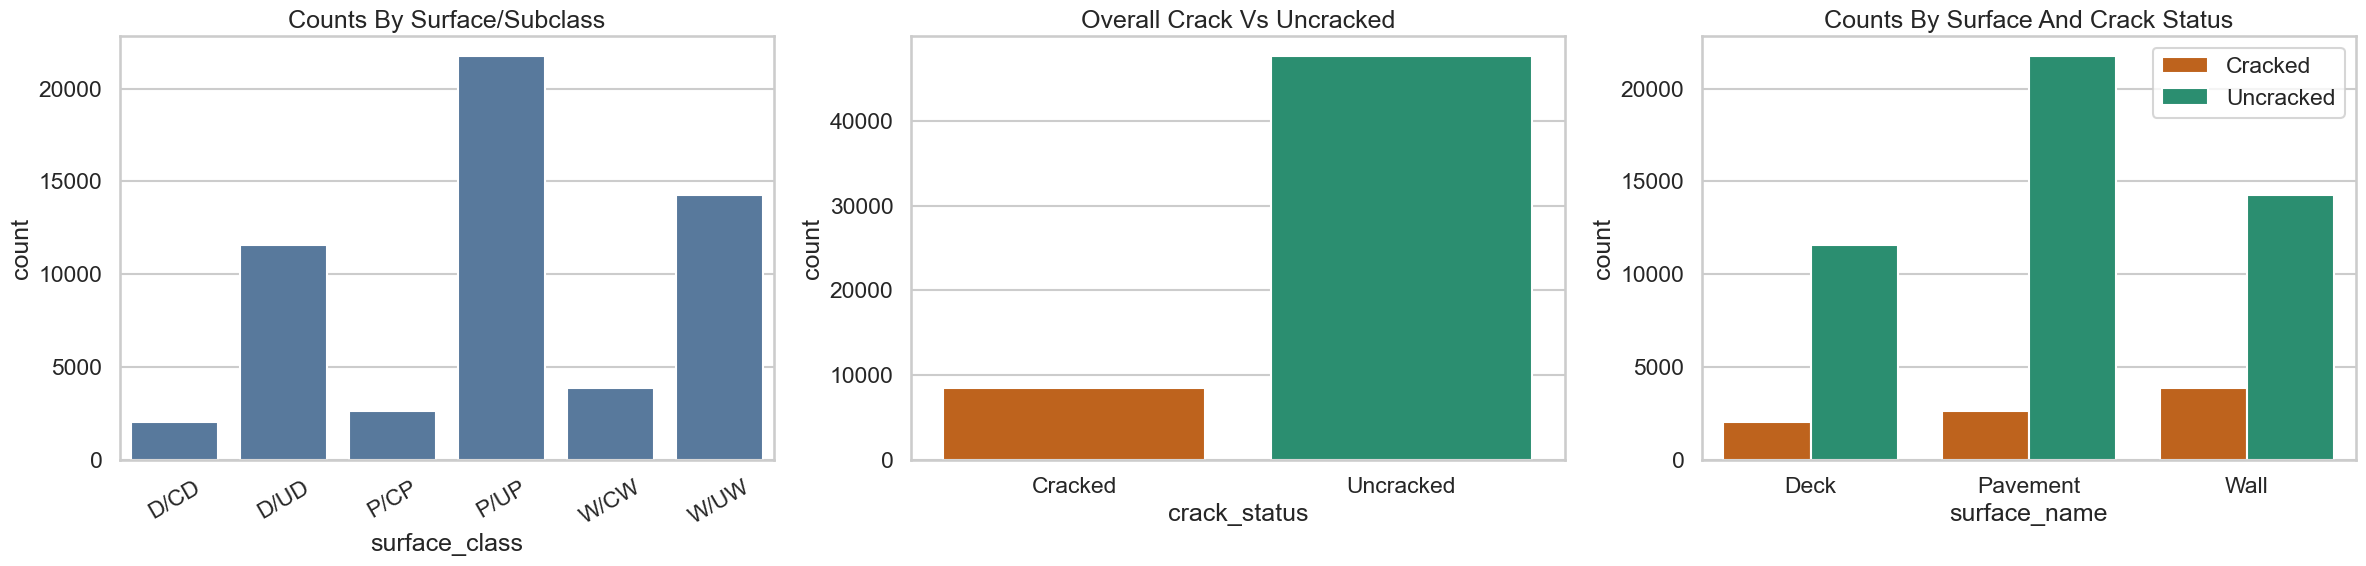

In [4]:
class_counts = (
    manifest_df["surface_class"]
    .value_counts()
    .sort_index()
    .rename_axis("surface_class")
    .reset_index(name="count")
)

crack_counts = (
    manifest_df["crack_status"]
    .value_counts()
    .reindex(["Cracked", "Uncracked"])
    .rename_axis("crack_status")
    .reset_index(name="count")
)

surface_crack_counts = (
    manifest_df.groupby(["surface_name", "crack_status"])
    .size()
    .reset_index(name="count")
)

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(f"Max/min imbalance across the six SDNET2018 folders: {imbalance_ratio:.2f}x")

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(data=class_counts, x="surface_class", y="count", ax=axes[0], color="#4c78a8")
axes[0].set_title("Counts By Surface/Subclass")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=crack_counts,
    x="crack_status",
    y="count",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Overall Crack Vs Uncracked")

sns.barplot(
    data=surface_crack_counts,
    x="surface_name",
    y="count",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[2],
)
axes[2].set_title("Counts By Surface And Crack Status")
axes[2].legend(title="")

plt.tight_layout()

balance_plot_path = PLOT_DIR / "sdnet2018_class_balance.png"
fig.savefig(balance_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved class balance plot to {balance_plot_path}")

display(class_counts)


## Pixel Intensity Exploration

Because these images are grayscale, simple intensity statistics can reveal whether one subgroup is systematically brighter, noisier, or more textured than another.


mean_intensity         std_intensity       
                       mean  median          mean median
crack_status                                            
Cracked              169.28  172.99         13.18   9.39
Uncracked            161.25  164.50         15.49  11.61

Saved pixel statistics plot to artifacts\plots\sdnet2018_pixel_statistics.png


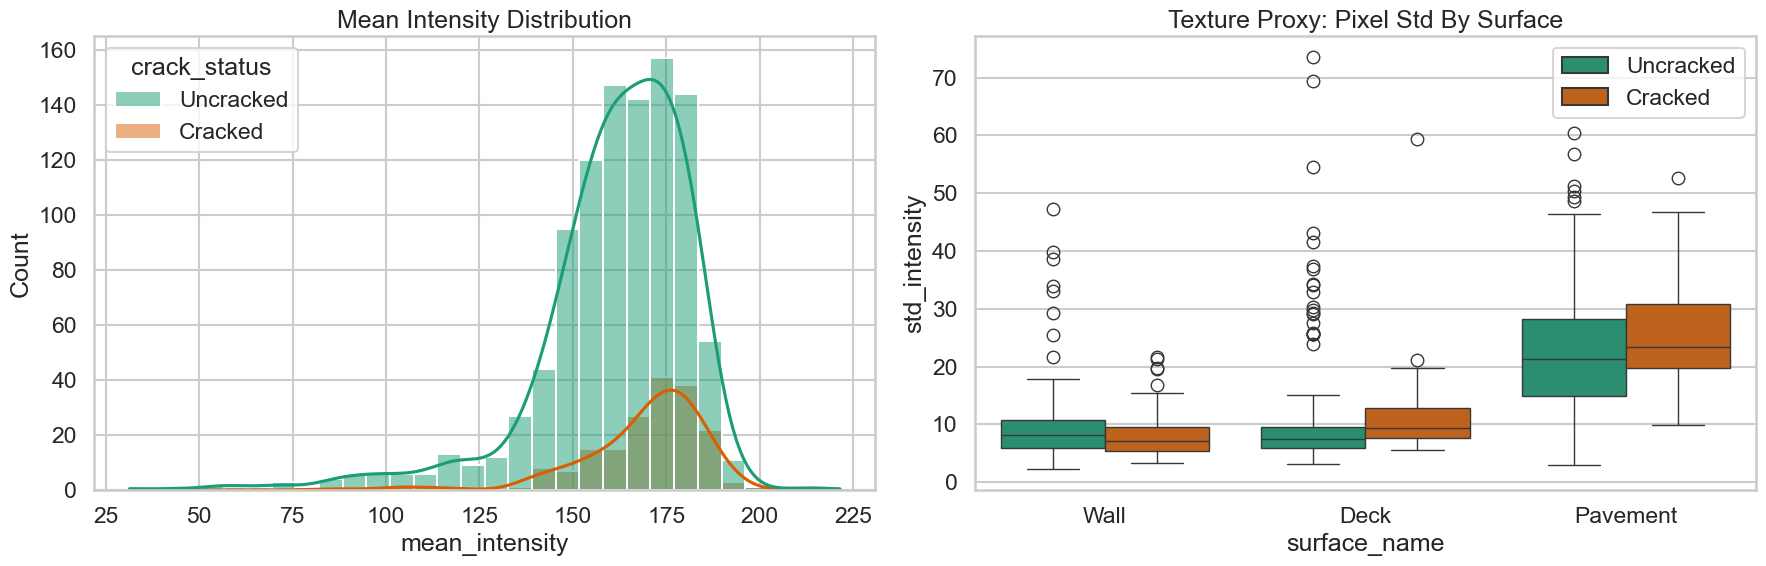

In [5]:
def summarize_pixel_statistics(df: pd.DataFrame, sample_size: int = 1200, seed: int = SEED) -> pd.DataFrame:
    sampled_df = df.sample(n=min(sample_size, len(df)), random_state=seed)
    rows = []

    for row in sampled_df.itertuples(index=False):
        image = load_grayscale(Path(row.path))
        rows.append(
            {
                "surface_name": row.surface_name,
                "crack_status": row.crack_status,
                "mean_intensity": float(image.mean()),
                "std_intensity": float(image.std()),
                "min_intensity": int(image.min()),
                "max_intensity": int(image.max()),
            }
        )

    return pd.DataFrame(rows)


pixel_stats_df = summarize_pixel_statistics(manifest_df)

summary_table = (
    pixel_stats_df.groupby("crack_status")[["mean_intensity", "std_intensity"]]
    .agg(["mean", "median"])
    .round(2)
)
display(summary_table)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(
    data=pixel_stats_df,
    x="mean_intensity",
    hue="crack_status",
    bins=30,
    kde=True,
    palette=CRACK_COLORS,
    ax=axes[0],
)
axes[0].set_title("Mean Intensity Distribution")

sns.boxplot(
    data=pixel_stats_df,
    x="surface_name",
    y="std_intensity",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[1],
)
axes[1].set_title("Texture Proxy: Pixel Std By Surface")
axes[1].legend(title="")

plt.tight_layout()

pixel_plot_path = PLOT_DIR / "sdnet2018_pixel_statistics.png"
fig.savefig(pixel_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved pixel statistics plot to {pixel_plot_path}")


## Representative Samples

A quick image grid helps verify that the cracked and uncracked subfolders actually contain the kinds of visual patterns we expect.


Saved sample grid to artifacts\plots\sdnet2018_sample_grid.png


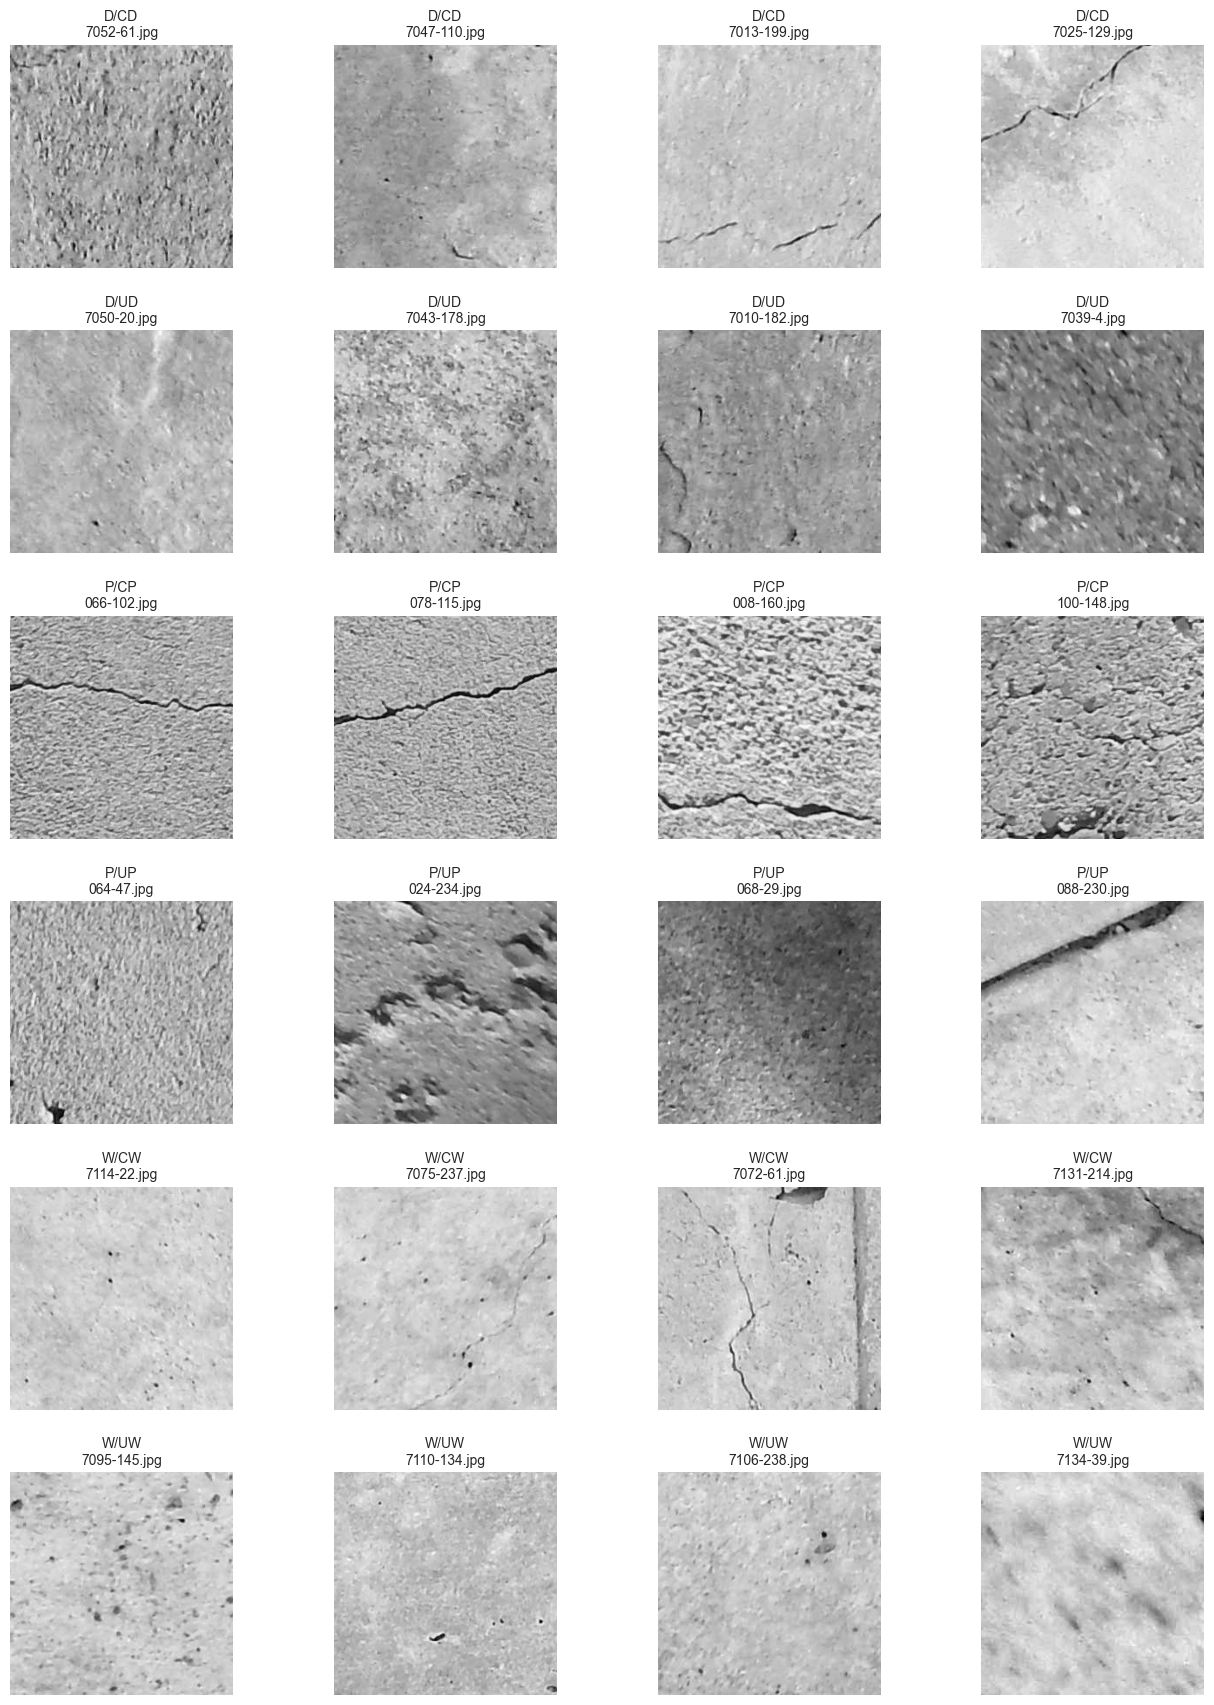

In [6]:
def show_examples_by_group(df: pd.DataFrame, samples_per_group: int = 4, seed: int = SEED) -> None:
    groups = sorted(df["surface_class"].unique())
    fig, axes = plt.subplots(
        len(groups),
        samples_per_group,
        figsize=(3.4 * samples_per_group, 2.9 * len(groups)),
    )

    for row_index, group in enumerate(groups):
        sampled_group = (
            df[df["surface_class"] == group]
            .sample(n=samples_per_group, random_state=seed)
            .reset_index(drop=True)
        )

        for column_index, sample in enumerate(sampled_group.itertuples(index=False)):
            ax = axes[row_index, column_index]
            image = load_grayscale(Path(sample.path))
            ax.imshow(image, cmap="gray")
            ax.set_title(f"{sample.surface_class}\n{Path(sample.relative_path).name}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()

    sample_plot_path = PLOT_DIR / "sdnet2018_sample_grid.png"
    fig.savefig(sample_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved sample grid to {sample_plot_path}")


show_examples_by_group(manifest_df, samples_per_group=4)


## Stratified Train, Validation, And Test Split

The split below preserves the six SDNET2018 subclass proportions so the evaluation sets stay representative.


In [7]:
def stratified_train_val_test_split(
    df: pd.DataFrame,
    stratify_col: str = "surface_class",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    train_df, temp_df = train_test_split(
        df,
        train_size=train_size,
        stratify=df[stratify_col],
        random_state=seed,
    )

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df[stratify_col],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_train_val_test_split(manifest_df)

split_manifest_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

split_summary = (
    split_manifest_df.groupby(["split", "surface_class"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

display(split_summary)
print(
    f"Train: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}"
)


surface_class,D/CD,D/UD,P/CP,P/UP,W/CW,W/UW
split,,,,,,
test,304,1740,391,3259,577,2143
train,1417,8116,1826,15208,2696,10001
validation,304,1739,391,3259,578,2143


Train: 39,264 | Validation: 8,414 | Test: 8,414


## Balancing Options For The Training Split

A good practice is to balance only the training set while keeping validation and test distributions untouched.

This notebook prepares:

- `balanced_train_downsample_df` to match the smallest training subgroup
- `balanced_train_oversample_df` to match the largest subgroup with replacement
- `binary_balanced_train_df` to balance only cracked vs uncracked labels
- class-weight tables that can be fed into a downstream model


,surface_class,original_train,downsampled_train,oversampled_train
0,D/CD,1417,1417,15208
1,D/UD,8116,1417,15208
2,P/CP,1826,1417,15208
3,P/UP,15208,1417,15208
4,W/CW,2696,1417,15208
5,W/UW,10001,1417,15208


,group,count,weight
0,D/CD,1417,4.6182
1,D/UD,8116,0.8063
2,P/CP,1826,3.5838
3,P/UP,15208,0.4303
4,W/CW,2696,2.4273
5,W/UW,10001,0.6543


,crack_status,original_train,binary_balanced_train
0,Cracked,5939,5939
1,Uncracked,33325,5939


,group,count,weight
0,Cracked,5939,3.3056
1,Uncracked,33325,0.5891


Saved balancing plot to artifacts\plots\sdnet2018_balancing_options.png


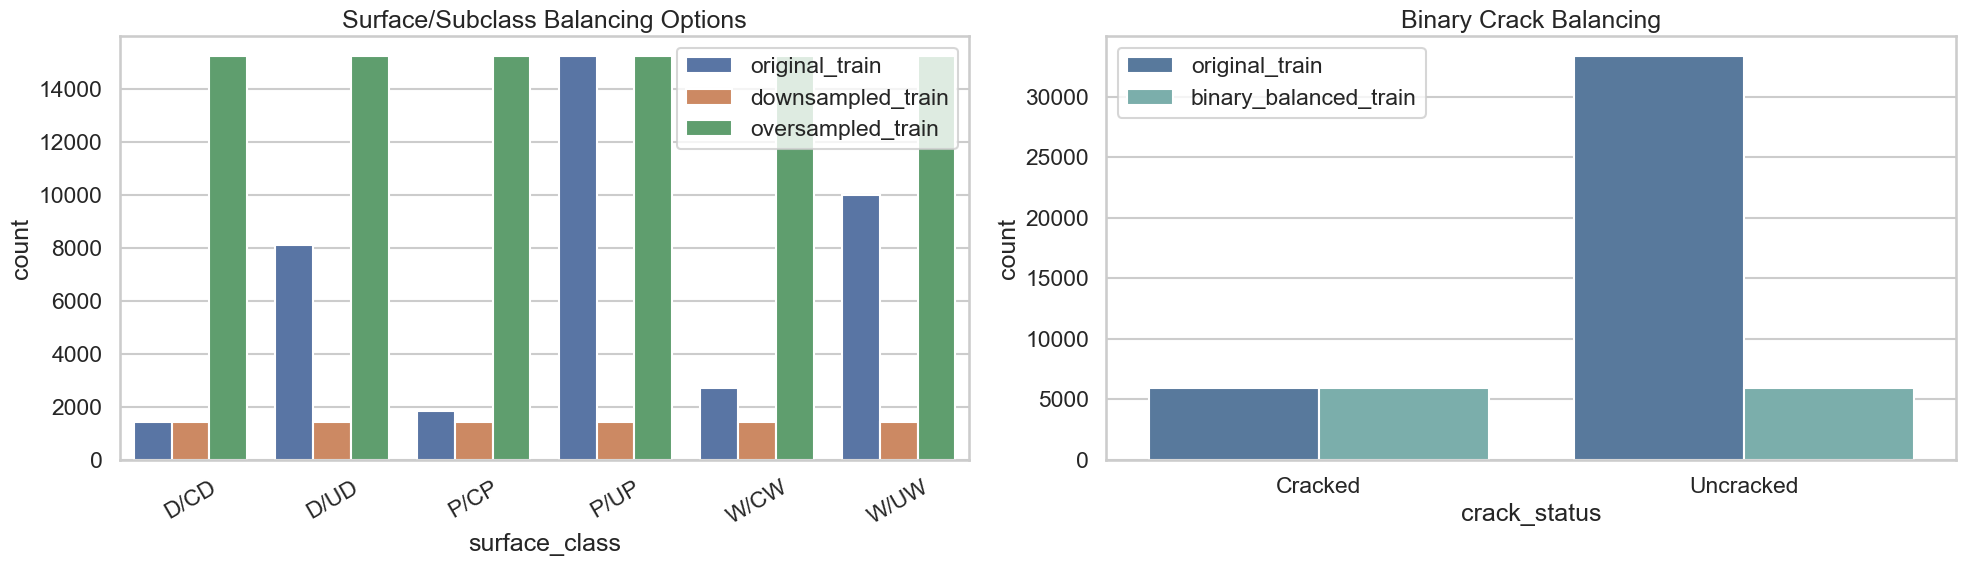

In [8]:
def make_balanced_subset(
    df: pd.DataFrame,
    group_col: str = "surface_class",
    strategy: str = "downsample",
    seed: int = SEED,
) -> pd.DataFrame:
    counts = df[group_col].value_counts().sort_index()

    if strategy == "downsample":
        target_count = int(counts.min())
        replace = False
    elif strategy == "oversample":
        target_count = int(counts.max())
        replace = True
    else:
        raise ValueError("strategy must be either 'downsample' or 'oversample'")

    balanced_frames = []

    for offset, group_name in enumerate(counts.index):
        group_df = df[df[group_col] == group_name]
        balanced_frames.append(
            group_df.sample(
                n=target_count,
                replace=replace,
                random_state=seed + offset,
            )
        )

    balanced_df = pd.concat(balanced_frames, ignore_index=True)
    return balanced_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def make_class_weight_table(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    counts = df[group_col].value_counts().sort_index()
    weights = counts.sum() / (len(counts) * counts)
    return pd.DataFrame(
        {
            "group": counts.index,
            "count": counts.values,
            "weight": weights.round(4).values,
        }
    )


balanced_train_downsample_df = make_balanced_subset(
    train_df,
    group_col="surface_class",
    strategy="downsample",
)

balanced_train_oversample_df = make_balanced_subset(
    train_df,
    group_col="surface_class",
    strategy="oversample",
)

binary_balanced_train_df = make_balanced_subset(
    train_df,
    group_col="crack_status",
    strategy="downsample",
)

multiclass_weight_table = make_class_weight_table(train_df, group_col="surface_class")
binary_weight_table = make_class_weight_table(train_df, group_col="crack_status")

surface_balance_comparison_df = pd.concat(
    [
        train_df["surface_class"].value_counts().sort_index().rename("original_train"),
        balanced_train_downsample_df["surface_class"]
        .value_counts()
        .sort_index()
        .rename("downsampled_train"),
        balanced_train_oversample_df["surface_class"]
        .value_counts()
        .sort_index()
        .rename("oversampled_train"),
    ],
    axis=1,
).reset_index(names="surface_class")

binary_balance_comparison_df = pd.concat(
    [
        train_df["crack_status"].value_counts().sort_index().rename("original_train"),
        binary_balanced_train_df["crack_status"]
        .value_counts()
        .sort_index()
        .rename("binary_balanced_train"),
    ],
    axis=1,
).reset_index(names="crack_status")

display(surface_balance_comparison_df)
display(multiclass_weight_table)
display(binary_balance_comparison_df)
display(binary_weight_table)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

surface_plot_df = surface_balance_comparison_df.melt(
    id_vars="surface_class",
    var_name="variant",
    value_name="count",
)
sns.barplot(
    data=surface_plot_df,
    x="surface_class",
    y="count",
    hue="variant",
    ax=axes[0],
)
axes[0].set_title("Surface/Subclass Balancing Options")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="")

binary_plot_df = binary_balance_comparison_df.melt(
    id_vars="crack_status",
    var_name="variant",
    value_name="count",
)
sns.barplot(
    data=binary_plot_df,
    x="crack_status",
    y="count",
    hue="variant",
    palette=["#4c78a8", "#72b7b2"],
    ax=axes[1],
)
axes[1].set_title("Binary Crack Balancing")
axes[1].legend(title="")

plt.tight_layout()

balancing_plot_path = PLOT_DIR / "sdnet2018_balancing_options.png"
fig.savefig(balancing_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved balancing plot to {balancing_plot_path}")


## Export Manifests For Downstream Training

The exported CSV files can be used directly by later classification or segmentation pipelines.


In [9]:
def export_manifest(frame: pd.DataFrame, destination: Path) -> None:
    export_frame = frame.copy()
    export_frame["path"] = export_frame["path"].astype(str)
    export_frame.to_csv(destination, index=False)


export_targets = {
    "sdnet2018_manifest.csv": manifest_df,
    "sdnet2018_split_manifest.csv": split_manifest_df,
    "sdnet2018_train_balanced_downsample.csv": balanced_train_downsample_df,
    "sdnet2018_train_balanced_oversample.csv": balanced_train_oversample_df,
    "sdnet2018_train_binary_balanced.csv": binary_balanced_train_df,
}

export_rows = []

for file_name, frame in export_targets.items():
    destination = MANIFEST_DIR / file_name
    export_manifest(frame, destination)
    export_rows.append({"file": destination.as_posix(), "rows": len(frame)})

display(pd.DataFrame(export_rows))


,file,rows
0,artifacts/manifests/sdnet2018_manifest.csv,56092
1,artifacts/manifests/sdnet2018_split_manifest.csv,56092
2,artifacts/manifests/sdnet2018_train_balanced_d...,8502
3,artifacts/manifests/sdnet2018_train_balanced_o...,91248
4,artifacts/manifests/sdnet2018_train_binary_bal...,11878


## Image Transformation Pipeline

These augmentations are mild enough to preserve crack structure while still improving robustness to viewpoint, illumination, and sensor variation.


In [10]:
def build_transforms(image_size: int = 224) -> tuple[A.Compose, A.Compose]:
    train_transform = A.Compose(
        [
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomRotate90(p=0.5),
            A.Affine(
                scale=(0.95, 1.05),
                translate_percent=(-0.04, 0.04),
                rotate=(-12, 12),
                shear=(-4, 4),
                interpolation=cv2.INTER_LINEAR,
                border_mode=cv2.BORDER_REFLECT_101,
                p=0.6,
            ),
            A.OneOf(
                [
                    A.CLAHE(clip_limit=(2.0, 4.0), tile_grid_size=(8, 8), p=1.0),
                    A.RandomBrightnessContrast(
                        brightness_limit=0.15,
                        contrast_limit=0.15,
                        brightness_by_max=True,
                        p=1.0,
                    ),
                    A.Sharpen(alpha=(0.1, 0.3), lightness=(0.9, 1.1), p=1.0),
                ],
                p=0.45,
            ),
            A.OneOf(
                [
                    A.GaussianBlur(blur_limit=(3, 5), sigma_limit=(0.5, 1.5), p=1.0),
                    A.MotionBlur(blur_limit=(3, 5), p=1.0),
                    A.GaussNoise(std_range=(0.02, 0.06), per_channel=False, p=1.0),
                ],
                p=0.25,
            ),
        ]
    )

    eval_transform = A.Compose([A.Resize(image_size, image_size)])
    return train_transform, eval_transform


train_transform, eval_transform = build_transforms(image_size=224)
train_transform


Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.2),
  RandomRotate90(p=0.5),
  Affine(p=0.6, balanced_scale=False, border_mode=4, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-12.0, 12.0), rotate_method='largest_box', scale={'x': (0.95, 1.05), 'y': (0.95, 1.05)}, shear={'x': (-4.0, 4.0), 'y': (-4.0, 4.0)}, translate_percent={'x': (-0.04, 0.04), 'y': (-0.04, 0.04)}, translate_px=None),
  OneOf([
    CLAHE(p=1.0, clip_limit=(2.0, 4.0), tile_grid_size=(8, 8)),
    RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), ensure_safe_range=False),
    Sharpen(p=1.0, alpha=(0.1, 0.3), kernel_size=5, lightness=(0.9, 1.1), method='kernel', sigma=1.0),
  ], p=0.45),
  OneOf([
    GaussianBlur(p=1.0, blur_limit=(3, 5), sigma_limit=(0.5, 1.5)),
    MotionBlur(p=1.0, 

## Augmentation Preview

Running the transformation pipeline on one cracked and one uncracked example is a quick way to verify that the augmentations are realistic rather than destructive.


Saved augmentation preview to artifacts\plots\sdnet2018_augmentation_preview.png


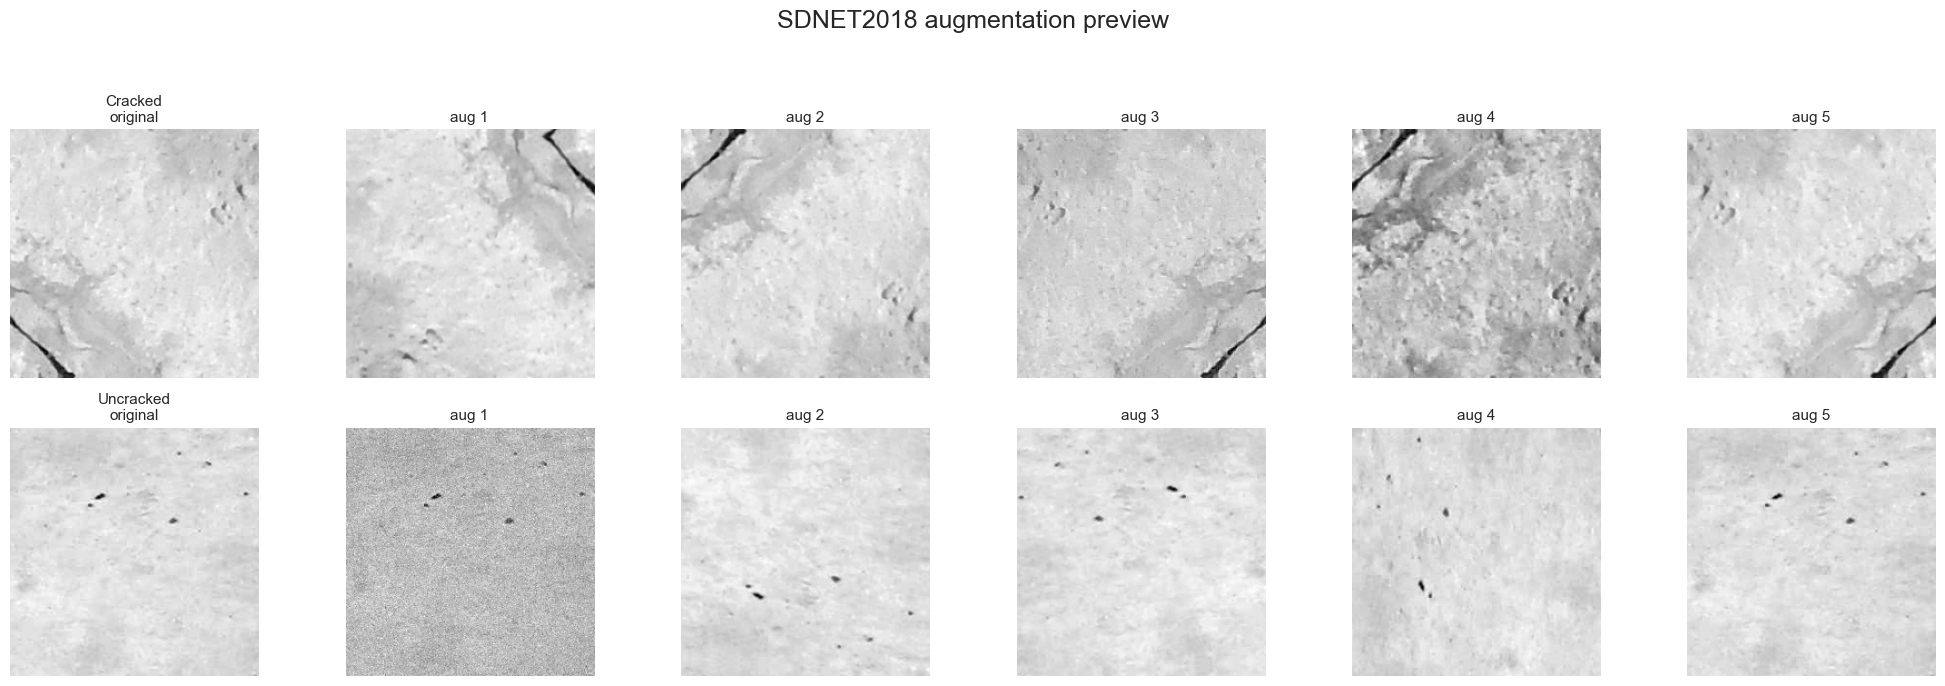

In [11]:
def preview_augmentation_rows(
    df: pd.DataFrame,
    transform: A.Compose,
    crack_statuses: tuple[str, ...] = ("Cracked", "Uncracked"),
    n_variants: int = 5,
    seed: int = SEED,
) -> None:
    fig, axes = plt.subplots(
        len(crack_statuses),
        n_variants + 1,
        figsize=(3.4 * (n_variants + 1), 3.4 * len(crack_statuses)),
    )

    if len(crack_statuses) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, crack_status in enumerate(crack_statuses):
        sample_row = (
            df[df["crack_status"] == crack_status]
            .sample(n=1, random_state=seed + row_index)
            .iloc[0]
        )

        image = load_grayscale(Path(sample_row.path))
        variants = [image] + [transform(image=image)["image"] for _ in range(n_variants)]

        for column_index, variant in enumerate(variants):
            ax = axes[row_index, column_index]
            ax.imshow(variant, cmap="gray")

            if column_index == 0:
                ax.set_title(f"{crack_status}\noriginal", fontsize=11)
            else:
                ax.set_title(f"aug {column_index}", fontsize=11)

            ax.axis("off")

    fig.suptitle("SDNET2018 augmentation preview", y=1.02, fontsize=18)
    plt.tight_layout()

    preview_plot_path = PLOT_DIR / "sdnet2018_augmentation_preview.png"
    fig.savefig(preview_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved augmentation preview to {preview_plot_path}")


preview_augmentation_rows(manifest_df, train_transform, n_variants=5)
